# 06: Additional Theoretical Forecasting

## Objective
Generate final **weekly** bed occupancy and staffing forecasts using the best performing model.

## Data Source
- **Hospital:** ADVENTHEALTH ORLANDO
- **Date Range:** 2020-07-19 to 2024-04-21 (197 weeks)
- **Target Variable:** `bed_occupancy` (weekly average occupied beds)
- **Forecast Horizon:** 8 weeks ahead

## Tasks
- Load best model based on evaluation (05_model_evaluation results)
- Generate 8-week bed occupancy forecasts
- Calculate confidence intervals
- Visualize forecasts with historical data
- Convert to staffing requirements

## Models Available
- **Structural** (04c): Best MAE from evaluation
- **SARIMAX** (04b): Seasonal ARIMA with exogenous features
- **LSTM** (04e): Neural network model
- **VAR** (04d): Vector autoregression


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from datetime import timedelta

try:
    import tensorflow as tf
    from tensorflow import keras
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False

# Setup paths
PROJECT_ROOT = '/content/hospital_occupancy_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'forecasts')

for path in [DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Google Drive mounting
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_occupancy_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'forecasts')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")

# Helper functions
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """Save file to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif filename.endswith('.pkl'):
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    print(f"✓ Saved to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif filename.endswith('.pkl'):
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")


def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")


def load_file(filename, local_path, drive_path=None):
    """Load file from Google Drive first, then local (Drive priority for Colab)."""
    # Try Google Drive first (persistent in Colab)
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.h5'):
                    return keras.models.load_model(drive_file, compile=False)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    # Try local
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.h5'):
            return keras.models.load_model(local_file, compile=False)

    return None


# Configuration
FORECAST_HORIZON = 8  # 8 weeks ahead
TRAIN_TEST_SPLIT = 0.8

✓ Google Drive already mounted
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_occupancy_forecasting


## Load Full Dataset

In [27]:
# Load weekly bed occupancy data
full_data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if full_data is not None:
    if 'bed_occupancy' in full_data.columns:
        target_series = full_data['bed_occupancy']
    else:
        occupancy_cols = [c for c in full_data.columns if 'occupancy' in c.lower() or 'bed' in c.lower()]
        target_series = full_data[occupancy_cols[0]] if occupancy_cols else full_data.iloc[:, 0]

    print(f"Loaded full dataset: {len(target_series)} weeks")
    print(f"Date range: {target_series.index.min()} to {target_series.index.max()}")
    print(f"Last recorded date: {target_series.index.max()}")
    print(f"\nForecast will start from: {target_series.index.max() + timedelta(weeks=1)}")
    print(f"Forecast will end on: {target_series.index.max() + timedelta(weeks=FORECAST_HORIZON)}")
else:
    print("⚠️  occupancy_with_features.csv not found")
    print("   Please run notebooks 01-04 first to create the data.")
    target_series = pd.Series(dtype=float)

Loaded full dataset: 197 weeks
Date range: 2020-07-19 00:00:00 to 2024-04-21 00:00:00
Last recorded date: 2024-04-21 00:00:00

Forecast will start from: 2024-04-28 00:00:00
Forecast will end on: 2024-06-16 00:00:00


## Load Best Model

Try to load models in order of performance (based on typical evaluation results):
1. Structural (usually best MAE)
2. SARIMAX
3. LSTM
4. VAR

In [28]:
best_model = None
model_name = None
model_type = None  # 'statsmodels', 'pmdarima', 'keras', 'var'

print("="*70)
print("LOADING BEST AVAILABLE MODEL")
print("="*70)

# Try Structural model first (often best performer)
print("\n1. Trying Structural model...")
structural_model = load_file('structural_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
if structural_model is not None:
    best_model = structural_model
    model_name = 'Structural'
    model_type = 'statsmodels'
    print(f"   ✓ Loaded Structural model")

# Try SARIMAX if structural not available
if best_model is None:
    print("\n2. Trying SARIMAX model...")
    sarimax_model = load_file('sarimax_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
    if sarimax_model is not None:
        best_model = sarimax_model
        model_name = 'SARIMAX'
        # Detect if it's pmdarima or statsmodels
        if hasattr(best_model, 'predict') and hasattr(best_model, 'order'):
            model_type = 'pmdarima'
        else:
            model_type = 'statsmodels'
        print(f"   ✓ Loaded SARIMAX model ({model_type})")

# Try VAR model
if best_model is None:
    print("\n3. Trying VAR model...")
    var_model = load_file('var_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
    if var_model is not None:
        best_model = var_model
        model_name = 'VAR'
        model_type = 'var'
        print(f"   ✓ Loaded VAR model")

# Try LSTM if others not available
if best_model is None and TENSORFLOW_AVAILABLE:
    print("\n4. Trying LSTM model...")
    lstm_model = load_file('lstm_model.h5', MODELS_PATH, DRIVE_MODELS_PATH)
    lstm_scaler = load_file('lstm_scaler.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
    if lstm_model is not None and lstm_scaler is not None:
        best_model = lstm_model
        model_name = 'LSTM'
        model_type = 'keras'
        print(f"   ✓ Loaded LSTM model")

if best_model is None:
    print("\n⚠️  No trained models found!")
    print("   Please run notebooks 04a-04e first to train models.")
else:
    print(f"\n✓ Using {model_name} model for forecasting")

LOADING BEST AVAILABLE MODEL

1. Trying Structural model...
   ✓ Loaded Structural model

✓ Using Structural model for forecasting


## Generate Final Forecast

In [29]:
forecast_df = pd.DataFrame()

if best_model is not None and len(target_series) > 0:
    print("="*70)
    print(f"GENERATING {FORECAST_HORIZON}-WEEK FORECAST USING {model_name}")
    print("="*70)

    last_date = target_series.index.max()
    forecast_index = pd.date_range(
        start=last_date + timedelta(weeks=1),
        periods=FORECAST_HORIZON,
        freq='W-SUN'  # Weekly on Sunday (matching our data)
    )

    forecast_values = None
    conf_int = None

    # ============================================================
    # GENERATE FUTURE EXOGENOUS FEATURES
    # ============================================================
    # For models with exogenous regressors, we need to provide future values
    def generate_future_exog(future_dates, historical_data):
        """Generate exogenous features for future forecast dates."""
        future_exog = pd.DataFrame(index=future_dates)

        # Cyclical features (deterministic - can calculate exactly)
        for date in future_dates:
            day_of_year = date.timetuple().tm_yday
            quarter = (date.month - 1) // 3 + 1

            future_exog.loc[date, 'day_of_year_sin'] = np.sin(2 * np.pi * day_of_year / 365)
            future_exog.loc[date, 'day_of_year_cos'] = np.cos(2 * np.pi * day_of_year / 365)
            future_exog.loc[date, 'quarter_sin'] = np.sin(2 * np.pi * quarter / 4)
            future_exog.loc[date, 'quarter_cos'] = np.cos(2 * np.pi * quarter / 4)
            future_exog.loc[date, 'week_of_year_sin'] = np.sin(2 * np.pi * date.isocalendar()[1] / 52)
            future_exog.loc[date, 'week_of_year_cos'] = np.cos(2 * np.pi * date.isocalendar()[1] / 52)
            future_exog.loc[date, 'month_sin'] = np.sin(2 * np.pi * date.month / 12)
            future_exog.loc[date, 'month_cos'] = np.cos(2 * np.pi * date.month / 12)

        # Lagged features - use last known values (carry forward)
        # These are already lagged, so we use the most recent available
        lagged_cols = ['ili_lag_1', 'temp_min_lag_1', 'covid_patient_pct_lag1', 'icu_occupancy_rate_lag1']
        for col in lagged_cols:
            if col in historical_data.columns:
                last_val = historical_data[col].dropna().iloc[-1] if not historical_data[col].dropna().empty else 0
                future_exog[col] = last_val

        # Holiday features - simple approach: check for major holidays
        # For simplicity, set to 0 (can be enhanced with holiday calendar)
        if 'holidays_in_week' in historical_data.columns:
            future_exog['holidays_in_week'] = 0

        return future_exog

    # Generate future exogenous features
    future_exog = generate_future_exog(forecast_index, full_data)
    print(f"\n   Generated future exogenous features: {list(future_exog.columns)}")

    try:
        if model_type == 'statsmodels':
            # Statsmodels structural or SARIMAX - needs exogenous features
            print(f"\nGenerating {model_name} forecast...")

            # Get the exogenous columns that the model was trained on
            # These should match what's in the model's exog_names
            if hasattr(best_model, 'model') and hasattr(best_model.model, 'exog_names') and best_model.model.exog_names:
                exog_names = best_model.model.exog_names
                print(f"   Model requires exog: {exog_names}")

                # Select only the columns the model needs
                exog_for_forecast = pd.DataFrame(index=forecast_index)
                for col in exog_names:
                    if col in future_exog.columns:
                        exog_for_forecast[col] = future_exog[col].values
                    else:
                        # Feature not available - use 0 or last known value from training data
                        if col in full_data.columns:
                            exog_for_forecast[col] = full_data[col].dropna().iloc[-1]
                        else:
                            exog_for_forecast[col] = 0
                            print(f"   ⚠️  Feature '{col}' not found, using 0")

                forecast_result = best_model.get_forecast(steps=FORECAST_HORIZON, exog=exog_for_forecast.values)
            else:
                # Model doesn't have exogenous features
                forecast_result = best_model.get_forecast(steps=FORECAST_HORIZON)

            forecast_values = forecast_result.predicted_mean.values
            conf_int_df = forecast_result.conf_int()
            conf_int = np.column_stack([
                conf_int_df.iloc[:, 0].values,  # lower
                conf_int_df.iloc[:, 1].values   # upper
            ])

        elif model_type == 'pmdarima':
            # pmdarima SARIMAX - may need exogenous features
            print(f"\nGenerating {model_name} forecast...")

            # Check if model was trained with exogenous features
            if hasattr(best_model, 'arima_res_') and best_model.arima_res_.model.exog is not None:
                # Model has exogenous features - we need to provide them
                n_exog = best_model.arima_res_.model.exog.shape[1]
                print(f"   Model requires {n_exog} exogenous features")

                # Use the future_exog we generated, select first n_exog columns
                exog_cols = list(future_exog.columns)[:n_exog]
                exog_for_forecast = future_exog[exog_cols].values

                forecast_values, conf_int = best_model.predict(
                    n_periods=FORECAST_HORIZON,
                    exogenous=exog_for_forecast,
                    return_conf_int=True
                )
            else:
                # No exogenous features
                forecast_values, conf_int = best_model.predict(
                    n_periods=FORECAST_HORIZON,
                    return_conf_int=True
                )
            forecast_values = np.array(forecast_values)

        elif model_type == 'var':
            # VAR model - forecast bed_occupancy
            print(f"\nGenerating {model_name} forecast...")
            # VAR requires last k_ar observations
            k_ar = best_model.k_ar
            n_vars = best_model.neqs  # Number of endogenous variables the model was trained on

            print(f"   VAR model: k_ar={k_ar}, n_vars={n_vars}")

            # Load the VAR training data to get last observations
            var_data = load_file('features_for_var.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
            if var_data is not None and 'bed_occupancy' in var_data.columns:
                # Get the column names the VAR model was trained on
                # The model was trained on specific columns - we need to match them
                # Priority: bed_occupancy + covid_patient_pct (or other KPIs)
                var_columns = ['bed_occupancy']
                for col in ['covid_patient_pct', 'ili', 'temp_min', 'temp_avg']:
                    if col in var_data.columns and len(var_columns) < n_vars:
                        var_columns.append(col)

                # Make sure we have exactly the right number of columns
                if len(var_columns) < n_vars:
                    # Add any available columns to match n_vars
                    for col in var_data.columns:
                        if col not in var_columns and len(var_columns) < n_vars:
                            var_columns.append(col)

                var_columns = var_columns[:n_vars]  # Ensure exact match
                print(f"   Using VAR columns: {var_columns}")

                # Get the last k_ar observations for these columns
                var_subset = var_data[var_columns].dropna()
                if len(var_subset) >= k_ar:
                    last_obs = var_subset.iloc[-k_ar:].values
                    forecast_result = best_model.forecast(last_obs, steps=FORECAST_HORIZON)

                    # Find bed_occupancy column index in our subset
                    bed_idx = var_columns.index('bed_occupancy')
                    forecast_values = forecast_result[:, bed_idx]

                    # VAR doesn't provide confidence intervals easily, estimate from historical std
                    historical_std = target_series.std()
                    conf_int = np.column_stack([
                        forecast_values - 1.96 * historical_std,
                        forecast_values + 1.96 * historical_std
                    ])
                else:
                    print(f"   ⚠️  Insufficient VAR data ({len(var_subset)} rows, need {k_ar})")
                    forecast_values = np.full(FORECAST_HORIZON, target_series.mean())
                    conf_int = None
            else:
                print("   ⚠️  VAR data not available, using fallback")
                forecast_values = np.full(FORECAST_HORIZON, target_series.mean())
                conf_int = None

        elif model_type == 'keras':
            # LSTM
            print(f"\nGenerating {model_name} forecast...")
            SEQUENCE_LENGTH = 3  # Should match training
            train_scaled = lstm_scaler.transform(target_series.values.reshape(-1, 1)).flatten()
            last_sequence = train_scaled[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, 1)

            forecast_scaled = []
            current_sequence = last_sequence.copy()
            for _ in range(FORECAST_HORIZON):
                next_pred = best_model.predict(current_sequence, verbose=0)
                next_pred = np.clip(next_pred, 0, 1)
                forecast_scaled.append(next_pred[0, 0])
                current_sequence = np.append(current_sequence[:, 1:, :],
                                            next_pred.reshape(1, 1, 1), axis=1)

            forecast_scaled = np.array(forecast_scaled).reshape(-1, 1)
            forecast_values = lstm_scaler.inverse_transform(forecast_scaled).flatten()

            # Estimate confidence interval from historical std
            historical_std = target_series.std()
            conf_int = np.column_stack([
                forecast_values - 1.96 * historical_std * 0.8,
                forecast_values + 1.96 * historical_std * 0.8
            ])

        # Create forecast DataFrame
        if forecast_values is not None:
            forecast_df = pd.DataFrame({
                'forecast': forecast_values,
                'lower_bound': conf_int[:, 0] if conf_int is not None else np.nan,
                'upper_bound': conf_int[:, 1] if conf_int is not None else np.nan
            }, index=forecast_index)

            # Ensure non-negative (bed occupancy can't be negative)
            forecast_df['forecast'] = forecast_df['forecast'].clip(lower=0)
            if conf_int is not None:
                forecast_df['lower_bound'] = forecast_df['lower_bound'].clip(lower=0)

            print(f"\n✓ Forecast generated for {len(forecast_df)} weeks")
            print(f"\nForecast summary:")
            print(forecast_df.describe())

            # Save forecast
            save_file(forecast_df, 'final_forecast.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)
            print(f"\n✓ Forecast saved to final_forecast.csv")

    except Exception as e:
        print(f"⚠️  Forecast generation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Cannot generate forecast - missing model or data")

GENERATING 8-WEEK FORECAST USING Structural

   Generated future exogenous features: ['day_of_year_sin', 'day_of_year_cos', 'quarter_sin', 'quarter_cos', 'week_of_year_sin', 'week_of_year_cos', 'month_sin', 'month_cos', 'ili_lag_1', 'holidays_in_week']

Generating Structural forecast...
   Model requires exog: ['quarter_sin', 'quarter_cos', 'day_of_year_sin', 'day_of_year_cos', 'ili_lag_1', 'holidays_in_week']

✓ Forecast generated for 8 weeks

Forecast summary:
          forecast  lower_bound  upper_bound
count     8.000000     8.000000     8.000000
mean   2304.008793  2151.504429  2456.513158
std      20.221881    49.699141    37.744668
min    2272.400348  2081.477805  2405.585417
25%    2284.876551  2109.815972  2424.291092
50%    2313.893402  2155.858939  2462.511290
75%    2317.801826  2181.277743  2476.595691
max    2323.940780  2226.590525  2517.138857
✓ Saved to local: /content/hospital_occupancy_forecasting/results/forecasts/final_forecast.csv
✓ Saved to Google Drive: /content

## Visualize Final Forecast

✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/forecasts/final_forecast_plot.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/forecasts/final_forecast_plot.png


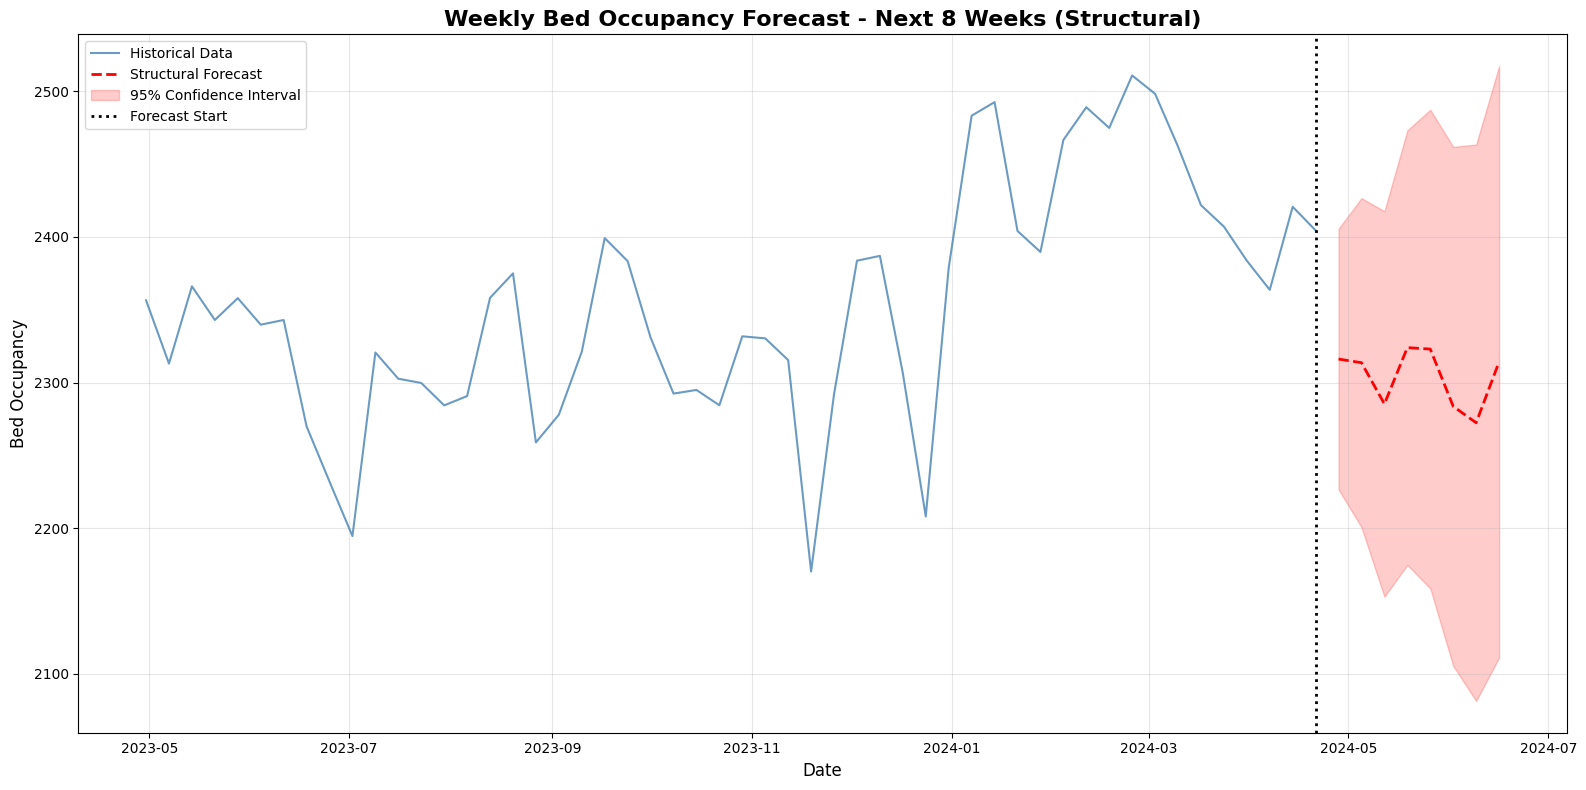

In [30]:
if len(forecast_df) > 0 and len(target_series) > 0:
    plt.figure(figsize=(16, 8))

    # Show last 52 weeks of historical data + forecast
    historical_weeks = min(52, len(target_series))
    historical_data = target_series.iloc[-historical_weeks:]

    plt.plot(historical_data.index, historical_data.values,
             label='Historical Data', color='steelblue', linewidth=1.5, alpha=0.8)
    plt.plot(forecast_df.index, forecast_df['forecast'].values,
             label=f'{model_name} Forecast', color='red', linewidth=2, linestyle='--')

    if 'lower_bound' in forecast_df.columns and not forecast_df['lower_bound'].isna().all():
        plt.fill_between(forecast_df.index,
                        forecast_df['lower_bound'].values,
                        forecast_df['upper_bound'].values,
                        alpha=0.2, color='red', label='95% Confidence Interval')

    plt.axvline(x=target_series.index.max(), color='black', linestyle=':',
                linewidth=2, label='Forecast Start')

    plt.title(f'Weekly Bed Occupancy Forecast - Next {FORECAST_HORIZON} Weeks ({model_name})',
              fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Bed Occupancy', fontsize=12)
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_plot(plt.gcf(), 'final_forecast_plot.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
             dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Cannot create visualization - missing forecast or data")

## Staffing Needs Forecasting

Convert bed occupancy forecasts to staffing requirements.

**Staffing Formula:**
- Nursing staff = Occupied beds × Staff-to-patient ratio
- Total staff = Nursing staff × Shift multiplier (3 shifts)


STAFFING NEEDS FORECASTING (Based on Bed Occupancy)

Calculating staffing from bed occupancy forecast...
✓ Saved to local: /content/hospital_occupancy_forecasting/results/forecasts/staffing_forecast.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/forecasts/staffing_forecast.csv

✓ Staffing forecast saved

STAFFING FORECAST SUMMARY

Configuration:
  Nurse-to-patient ratio: 1.5
  Support staff ratio: 0.3
  Minimum staff per shift: 20
  Shifts per day: 3

Forecasted Staffing (8 weeks):
  Average beds occupied: 2304
  Average staff per shift: 4147
  Average total daily staff: 12442
  Peak staff per shift: 4183

  95% Staffing Range:
    Low estimate: 11618 staff/day
    High estimate: 13265 staff/day
    Average uncertainty: ±823 staff/day
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/forecasts/staffing_forecast.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/forecasts/staffi

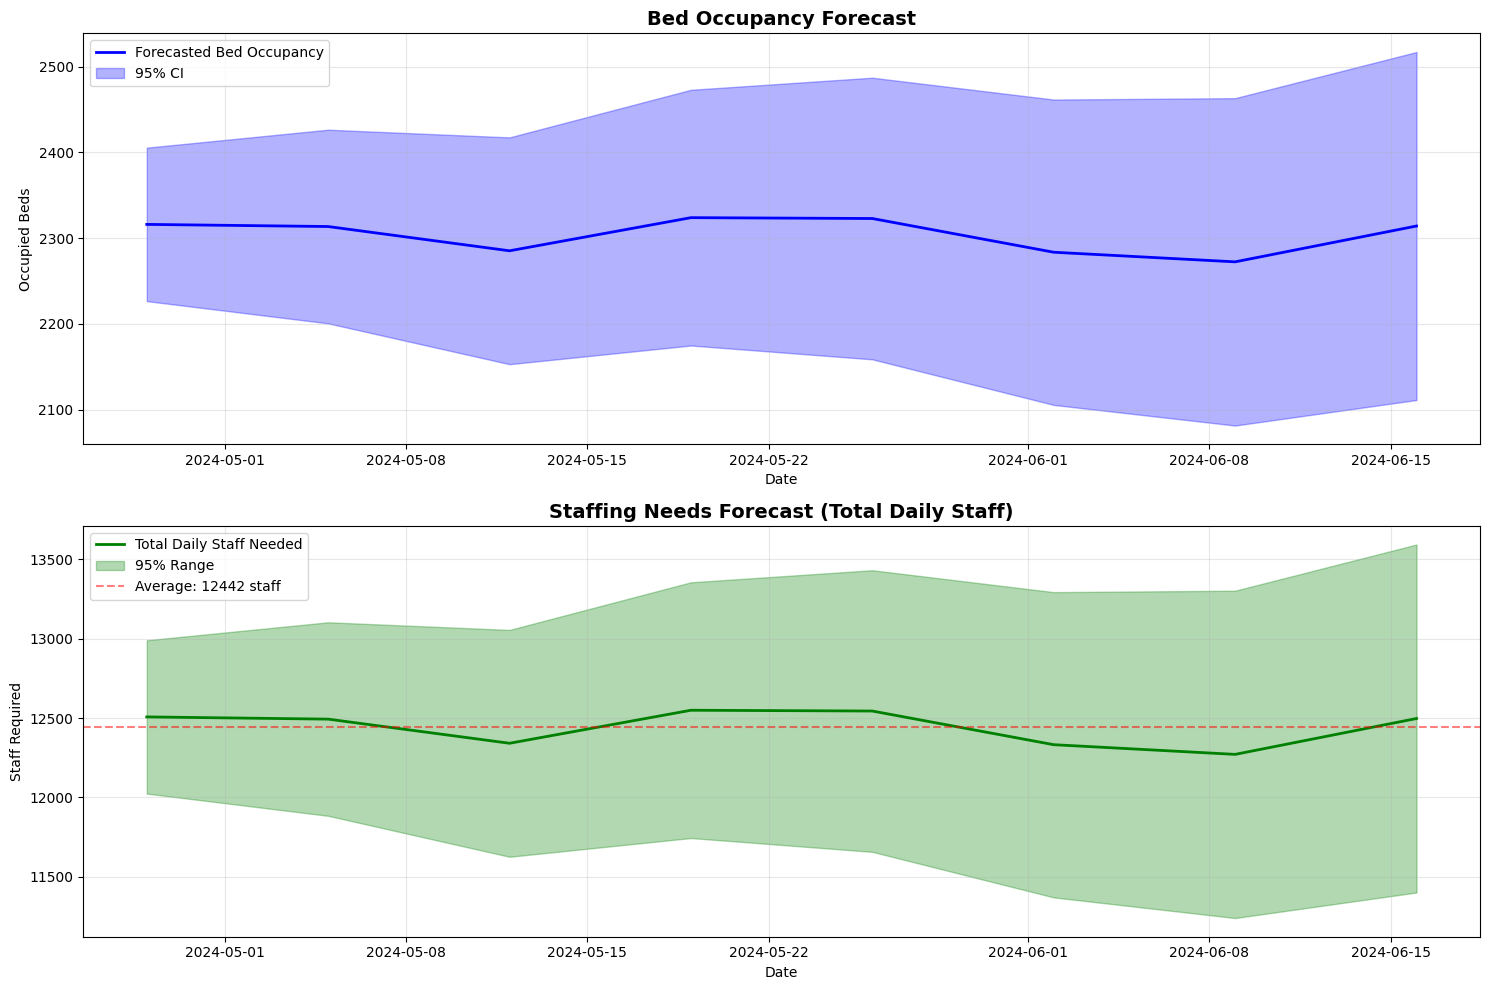


DETAILED WEEKLY FORECAST

Week         Date         Beds       Staff/Shift    Total Staff 
------------------------------------------------------------
Week 1      2024-04-28   2316       4169           12507       
Week 2      2024-05-05   2314       4164           12493       
Week 3      2024-05-12   2285       4114           12341       
Week 4      2024-05-19   2324       4183           12549       
Week 5      2024-05-26   2323       4181           12544       
Week 6      2024-06-02   2284       4111           12332       
Week 7      2024-06-09   2272       4090           12271       
Week 8      2024-06-16   2314       4166           12497       


In [31]:
print("="*70)
print("STAFFING NEEDS FORECASTING (Based on Bed Occupancy)")
print("="*70)

# Configuration for staffing calculations
NURSE_TO_PATIENT_RATIO = 1.5  # Nurses per occupied bed (industry standard: 1.2-2.0)
SUPPORT_STAFF_RATIO = 0.3     # Support staff per occupied bed (techs, aides, etc.)
MIN_STAFF_PER_SHIFT = 20      # Minimum staff per shift
SHIFT_MULTIPLIER = 3          # 3 shifts per day

def calculate_staffing_needs(bed_occupancy, lower_bound=None, upper_bound=None):
    """
    Calculate staffing needs from bed occupancy forecast.

    Parameters:
    - bed_occupancy: Forecasted number of occupied beds
    - lower_bound: Lower confidence bound for occupancy
    - upper_bound: Upper confidence bound for occupancy

    Returns:
    - Dictionary with staffing calculations
    """
    # Base staffing per shift
    nursing_staff = bed_occupancy * NURSE_TO_PATIENT_RATIO
    support_staff = bed_occupancy * SUPPORT_STAFF_RATIO
    staff_per_shift = np.maximum(MIN_STAFF_PER_SHIFT, nursing_staff + support_staff)

    # Total daily staff (across 3 shifts)
    total_daily_staff = staff_per_shift * SHIFT_MULTIPLIER

    result = {
        'staff_per_shift': staff_per_shift.round().astype(int),
        'total_daily_staff': total_daily_staff.round().astype(int),
        'nursing_staff_per_shift': nursing_staff.round().astype(int),
        'support_staff_per_shift': support_staff.round().astype(int)
    }

    # Calculate confidence intervals if provided
    if lower_bound is not None and upper_bound is not None:
        # For staffing: upper bound occupancy = more staff needed (worst case)
        worst_case_staff = np.maximum(MIN_STAFF_PER_SHIFT,
                                      upper_bound * (NURSE_TO_PATIENT_RATIO + SUPPORT_STAFF_RATIO))
        best_case_staff = np.maximum(MIN_STAFF_PER_SHIFT,
                                     lower_bound * (NURSE_TO_PATIENT_RATIO + SUPPORT_STAFF_RATIO))

        result['staff_per_shift_high'] = (worst_case_staff * SHIFT_MULTIPLIER).round().astype(int)
        result['staff_per_shift_low'] = (best_case_staff * SHIFT_MULTIPLIER).round().astype(int)
        result['staffing_range'] = (result['staff_per_shift_high'] - result['staff_per_shift_low'])

    return result


if len(forecast_df) > 0:
    print("\nCalculating staffing from bed occupancy forecast...")

    bed_occupancy_forecast = forecast_df['forecast'].values
    forecast_dates = forecast_df.index

    # Calculate staffing
    if 'lower_bound' in forecast_df.columns and not forecast_df['lower_bound'].isna().all():
        staffing = calculate_staffing_needs(
            bed_occupancy_forecast,
            lower_bound=forecast_df['lower_bound'].values,
            upper_bound=forecast_df['upper_bound'].values
        )
        has_ci = True
    else:
        staffing = calculate_staffing_needs(bed_occupancy_forecast)
        has_ci = False

    # Create staffing DataFrame
    staffing_df = pd.DataFrame({
        'date': forecast_dates,
        'forecasted_beds': bed_occupancy_forecast.round().astype(int),
        'staff_per_shift': staffing['staff_per_shift'],
        'total_daily_staff': staffing['total_daily_staff'],
        'nursing_staff': staffing['nursing_staff_per_shift'],
        'support_staff': staffing['support_staff_per_shift']
    })

    if has_ci:
        staffing_df['staff_high'] = staffing['staff_per_shift_high']
        staffing_df['staff_low'] = staffing['staff_per_shift_low']

    # Save staffing forecast
    save_file(staffing_df, 'staffing_forecast.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)
    print(f"\n✓ Staffing forecast saved")

    # Display summary
    print(f"\n{'='*70}")
    print("STAFFING FORECAST SUMMARY")
    print(f"{'='*70}")
    print(f"\nConfiguration:")
    print(f"  Nurse-to-patient ratio: {NURSE_TO_PATIENT_RATIO}")
    print(f"  Support staff ratio: {SUPPORT_STAFF_RATIO}")
    print(f"  Minimum staff per shift: {MIN_STAFF_PER_SHIFT}")
    print(f"  Shifts per day: {SHIFT_MULTIPLIER}")

    print(f"\nForecasted Staffing ({FORECAST_HORIZON} weeks):")
    print(f"  Average beds occupied: {bed_occupancy_forecast.mean():.0f}")
    print(f"  Average staff per shift: {staffing['staff_per_shift'].mean():.0f}")
    print(f"  Average total daily staff: {staffing['total_daily_staff'].mean():.0f}")
    print(f"  Peak staff per shift: {staffing['staff_per_shift'].max():.0f}")

    if has_ci:
        print(f"\n  95% Staffing Range:")
        print(f"    Low estimate: {staffing['staff_per_shift_low'].mean():.0f} staff/day")
        print(f"    High estimate: {staffing['staff_per_shift_high'].mean():.0f} staff/day")
        print(f"    Average uncertainty: ±{staffing['staffing_range'].mean()//2:.0f} staff/day")

    # Create visualization
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Plot 1: Bed occupancy forecast
    axes[0].plot(forecast_dates, bed_occupancy_forecast,
                label='Forecasted Bed Occupancy', color='blue', linewidth=2)
    if has_ci:
        axes[0].fill_between(forecast_dates,
                            forecast_df['lower_bound'].values,
                            forecast_df['upper_bound'].values,
                            alpha=0.3, color='blue', label='95% CI')
    axes[0].set_title('Bed Occupancy Forecast', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Occupied Beds')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Staffing needs
    axes[1].plot(forecast_dates, staffing['total_daily_staff'],
                label='Total Daily Staff Needed', color='green', linewidth=2)
    if has_ci:
        axes[1].fill_between(forecast_dates,
                            staffing['staff_per_shift_low'],
                            staffing['staff_per_shift_high'],
                            alpha=0.3, color='green', label='95% Range')
    axes[1].axhline(y=staffing['total_daily_staff'].mean(),
                   color='red', linestyle='--', alpha=0.5,
                   label=f"Average: {staffing['total_daily_staff'].mean():.0f} staff")
    axes[1].set_title('Staffing Needs Forecast (Total Daily Staff)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Staff Required')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_plot(plt.gcf(), 'staffing_forecast.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
             dpi=300, bbox_inches='tight')
    plt.show()

    # Print detailed forecast table
    print(f"\n{'='*70}")
    print("DETAILED WEEKLY FORECAST")
    print(f"{'='*70}")
    print(f"\n{'Week':<12} {'Date':<12} {'Beds':<10} {'Staff/Shift':<14} {'Total Staff':<12}")
    print("-"*60)
    for i, (date, row) in enumerate(staffing_df.iterrows()):
        print(f"Week {i+1:<6} {str(row['date'].date()):<12} {row['forecasted_beds']:<10} "
              f"{row['staff_per_shift']:<14} {row['total_daily_staff']:<12}")

else:
    print("\n⚠️  No forecast available for staffing calculation")
    print("   Generate forecast first")

## Summary

This notebook:
- ✅ Loaded full dataset and best performing model
- ✅ Generated 8-week **weekly** bed occupancy forecast
- ✅ Created forecast visualization with confidence intervals
- ✅ Calculated staffing needs from bed occupancy forecast
- ✅ Saved all results to `results/forecasts/`

**Output Files:**
- `final_forecast.csv` - Weekly bed occupancy forecast with confidence intervals
- `staffing_forecast.csv` - Staffing requirements based on forecast
- `final_forecast_plot.png` - Forecast visualization
- `staffing_forecast.png` - Staffing visualization

**Next Steps:**
- Use forecast and staffing results in your final report
- Compare against actual values when available